# Klasifikasi Lesi Kulit: Jinak (Benign) vs Ganas (Malignant)
### Penggabungan & Harmonisasi Dataset HAM10000, ISIC 2017, dan ISIC 2019

Notebook ini menggabungkan 3 dataset foto penyakit kulit populer ke dalam satu standar medis, lalu mengelompokkannya jadi 2 kategori sederhana:
- **Jinak / Benign (0):** Tahi lalat atau benjolan biasa yang aman (tidak berbahaya).
- **Ganas / Malignant (1):** Kanker kulit yang berbahaya dan butuh penanganan medis cepat.

**Alur Kerja Step-by-Step:**
1. **Persiapan:** Siapkan pustaka Python dan folder dataset.
2. **Scan Foto:** Kumpulkan semua file gambar fisik dari 3 dataset.
3. **Pasang Label:** Hubungkan foto dengan catatan diagnosis medis (Ground Truth CSV).
4. **Hapus Duplikat:** Buang foto kembar agar model AI tidak menghafal gambar yang sama.
5. **Cek Kelas Asli:** Lihat daftar penyakit bawaan dari masing-masing dataset.
6. **Samakan Nama (Harmonisasi):** Ubah istilah penyakit yang berbeda-beda jadi 1 nama standar dunia.
7. **Grafik Sebaran:** Lihat sebaran penyakit kulit dalam bentuk grafik.
8. **Rujukan Ilmiah:** Tentukan aturan jinak vs ganas berdasarkan jurnal ilmiah internasional.
9. **Aturan Biner:** Tentukan pengelompokan 8 penyakit ke Benign (0) atau Malignant (1).
10. **Terapkan Biner:** Pasang label biner dan buang data yang tidak jelas (`UNK`).
11. **Rekapitulasi:** Cek tabel rekapitulasi dan visualisasi perbandingan akhir.
12. **Simpan Data:** Ekspor dataset final yang bersih dan siap latih ke file CSV.
13. **Cek Contoh Foto:** Tampilkan contoh foto asli untuk lesi Jinak dan Ganas.

## Langkah 1: Import Library & Siapkan Lokasi Dataset
Kita siapkan dulu pustaka Python (seperti pandas, numpy, matplotlib) dan daftarkan lokasi folder dari 3 dataset:
- **HAM10000** (2018): 2 folder gambar + 1 file metadata diagnosis.
- **ISIC 2019**: Folder Training & Test + Ground Truth CSV (format 9 kolom one-hot).
- **ISIC 2017**: Folder Training, Validation & Test v2 + Ground Truth CSV.

In [1]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

# Deteksi root folder dataset
folder_aktif = os.getcwd()
if os.path.exists(os.path.join(folder_aktif, 'Dataset')):
    ROOT = os.path.join(folder_aktif, 'Dataset')
elif os.path.exists(os.path.join(os.path.dirname(folder_aktif), 'Dataset')):
    ROOT = os.path.join(os.path.dirname(folder_aktif), 'Dataset')
else:
    ROOT = r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset"

print(f"Dataset root: {ROOT}")

# Konfigurasi dataset
SOURCES = {
    'ham10000': {
        'year': '2018', 'split': 'train', 'gt_format': 'ham_dx',
        'img_dirs': [
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_1'),
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_2'),
        ],
        'gt_path': os.path.join(ROOT, 'HAM10K', 'HAM10000_metadata'),
    },
    'isic_2019_train': {
        'year': '2019', 'split': 'train', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Metadata.csv'),
    },
    'isic_2019_test': {
        'year': '2019', 'split': 'test', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_GroundTruth.csv'),
    },
    'isic_2017_train': {
        'year': '2017', 'split': 'train', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Part3_GroundTruth.csv'),
    },
    'isic_2017_val': {
        'year': '2017', 'split': 'val', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Part3_GroundTruth.csv'),
    },
    'isic_2017_test': {
        'year': '2017', 'split': 'test', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Part3_GroundTruth.csv'),
    },
}

print(f"Total dataset sumber: {len(SOURCES)}")


Dataset root: C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset
Total dataset sumber: 6


## Langkah 2: Scan Seluruh File Foto dari 3 Dataset
Di tahap ini, kita cari dan kumpulkan semua file gambar fisik (`.jpg` / `.jpeg`) yang ada di folder dataset.
- **Tujuan:** Mengetahui berapa total foto mentah yang kita miliki sebelum dibersihkan.
- **Target:** Menemukan **46.334 foto**.

In [2]:
# 1. Scan file gambar fisik (.jpg / .jpeg) dari tiap folder dataset
IMG_EXT = ('.jpg', '.jpeg')
all_images = []

for source, info in SOURCES.items():
    if 'img_dirs' in info:
        for d in info['img_dirs']:
            if os.path.exists(d):
                for f in os.listdir(d):
                    if f.lower().endswith(IMG_EXT):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(d, f)
                        })
    else:
        d = info.get('img_dir')
        if d and os.path.exists(d):
            for root_dir, _, files in os.walk(d):
                if '__MACOSX' in root_dir:
                    continue
                for f in files:
                    if f.lower().endswith(IMG_EXT) and not f.startswith('._'):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(root_dir, f)
                        })

df_images = pd.DataFrame(all_images)
print(f"Gambar fisik terindeks : {len(df_images):,} citra")

Gambar fisik terindeks : 46,334 citra


## Langkah 3: Pasangkan Label Diagnosis dari File CSV
Foto saja belum cukup untuk melatih AI, kita butuh tahu penyakit apa di setiap foto. Di sini kita baca file CSV Ground Truth masing-masing dataset lalu kita tempelkan label aslinya ke tiap foto.
- **Target:** Seluruh **46.334 foto** berhasil terpasang label diagnosis aslinya.

In [3]:
# 2. Baca label medis dari file CSV ground truth masing-masing dataset
ground_truth_dfs = {}
source_label_maps = {}

for source, info in SOURCES.items():
    p = info.get('gt_path')
    fmt = info.get('gt_format')
    if not p or not os.path.exists(p):
        continue
    
    df_gt = pd.read_csv(p)
    id_col = next((c for c in ['image_id', 'image', 'image_name', 'isic_id'] if c in df_gt.columns), df_gt.columns[0])
    df_gt['image_id'] = df_gt[id_col].astype(str).str.replace('.jpg', '', regex=False)
    ground_truth_dfs[source] = df_gt
    
    m = {}
    if fmt == 'ham_dx':
        for _, row in df_gt.iterrows():
            m[row['image_id']] = str(row['dx']).lower()
    elif fmt == '2017':
        for _, row in df_gt.iterrows():
            if row.get('melanoma') == 1.0:
                m[row['image_id']] = 'melanoma'
            elif row.get('seborrheic_keratosis') == 1.0:
                m[row['image_id']] = 'seborrheic_keratosis'
            else:
                m[row['image_id']] = 'nevus'
    elif fmt == 'onehot9':
        cols = [c for c in df_gt.columns if c not in ('image_id', id_col, 'score_weight', 'validation_weight')]
        for _, row in df_gt.iterrows():
            assigned = None
            for c in cols:
                if row.get(c) == 1.0:
                    assigned = c
                    break
            if assigned:
                m[row['image_id']] = assigned
    source_label_maps[source] = m

# Pasangkan label asli ke masing-masing foto sesuai dataset sumbernya
df_images['original_label'] = df_images.apply(
    lambda r: source_label_maps.get(r['source'], {}).get(r['image_id']), 
    axis=1
)

print(f"Gambar berlabel CSV     : {df_images['original_label'].notna().sum():,} citra")

Gambar berlabel CSV     : 46,334 citra


## Langkah 4: Hapus Foto Duplikat (Prioritas HAM10000)
Beberapa foto di ISIC 2019 dan 2017 sebenarnya adalah foto yang sama persis dengan dataset HAM10000.
- **Rujukan Ilmiah:** Mengacu pada protokol deduplikasi **Ichim et al. (MDPI Cancers 2023)** (rujukan yang sama persis dengan skenario multiclass).
- **Aturan kita:** Dataset benchmark HAM10000 (10.015 foto) kita jaga 100% utuh. Jika ada foto kembar di ISIC 2019/2017, foto kembar tersebut yang kita hapus.
- **Hasil:** Dari 46.334 foto mentah, ditemukan **10.735 foto kembar**, menyisakan **35.599 foto unik** yang bersih.

In [4]:
# Prioritas dataset: HAM10000 dipertahankan 100% utuh
PRIORITY_ORDER = [
    'ham10000',
    'isic_2019_train',
    'isic_2019_test',
    'isic_2017_train',
    'isic_2017_val',
    'isic_2017_test'
]

priority_map = {src: i for i, src in enumerate(PRIORITY_ORDER)}
df_all = df_images.copy()
df_all['priority'] = df_all['source'].map(priority_map)

# Hapus duplikat berdasarkan image_id
df_sorted = df_all.sort_values(by=['image_id', 'priority'])
df_clean = df_sorted.drop_duplicates(subset='image_id', keep='first').copy()
df_dropped = df_sorted[~df_sorted.index.isin(df_clean.index)].copy()

# Petakan sumber yang mempertahankan gambar
kept_map = df_clean.set_index('image_id')['source'].to_dict()
df_dropped['kept_in_source'] = df_dropped['image_id'].map(kept_map)

# Ringkasan sebelum vs sesudah deduplikasi
before_counts = df_all['source'].value_counts()
after_counts = df_clean['source'].value_counts()
dropped_counts = df_dropped['source'].value_counts()

rows_summary = []
for src in PRIORITY_ORDER:
    b = before_counts.get(src, 0)
    a = after_counts.get(src, 0)
    d = dropped_counts.get(src, 0)
    pct = round((d / b * 100), 2) if b > 0 else 0
    
    dropped_src = df_dropped[df_dropped['source'] == src]
    if len(dropped_src) > 0:
        detail = "; ".join([f"{k} ({v:,})" for k, v in dropped_src['kept_in_source'].value_counts().items()])
    else:
        detail = "-"
        
    rows_summary.append({
        'Source': src,
        'Before': b,
        'Dropped': d,
        'After': a,
        '% Drop': f"{pct}%",
        'Kept In': detail
    })

df_dedup_summary = pd.DataFrame(rows_summary)
display(df_dedup_summary)

print(f"Total awal    : {len(df_all):,} citra")
print(f"Duplikat      : {len(df_dropped):,} citra")
print(f"Setelah bersih: {len(df_clean):,} citra")


,Source,Before,Dropped,After,% Drop,Kept In
0,ham10000,10015,0,10015,0.0%,-
1,isic_2019_train,25331,10015,15316,39.54%,"ham10000 (10,015)"
2,isic_2019_test,8238,0,8238,0.0%,-
3,isic_2017_train,2000,717,1283,35.85%,isic_2019_train (717)
4,isic_2017_val,150,2,148,1.33%,isic_2019_train (2)
5,isic_2017_test,600,1,599,0.17%,isic_2019_train (1)


Total awal    : 46,334 citra
Duplikat      : 10,735 citra
Setelah bersih: 35,599 citra


## Langkah 5: Eksplorasi Penyakit Asli di Setiap Dataset
Sebelum disatukan, mari kita lihat penyakit apa saja yang ada di masing-masing dataset:
- **HAM10000:** Ada 7 jenis penyakit kulit (ditulis dengan singkatan huruf kecil, misal: `nv`, `mel`).
- **ISIC 2019:** Ada 9 kategori (8 penyakit + 1 kategori `UNK` / tidak diketahui).
- **ISIC 2017:** Ada 3 kategori saja (nama lengkap: `nevus`, `melanoma`, `seborrheic_keratosis`).

In [5]:
# =========================================================================
# 3.1 DAFTAR SELURUH KELAS ASLI DATASET HAM10000 (7 KELAS)
# =========================================================================
HAM_INFO = {
    'nv': ('Melanocytic Nevus', 'Tahi lalat jinak (melanositik)', 'Benign (0)'),
    'mel': ('Melanoma', 'Kanker kulit ganas dari melanosit', 'Malignant (1)'),
    'bkl': ('Benign Keratosis', 'Keratosis seboroik / solar lentigo jinak', 'Benign (0)'),
    'bcc': ('Basal Cell Carcinoma', 'Karsinoma sel basal ganas', 'Malignant (1)'),
    'akiec': ('Actinic Keratosis', 'Lesi pra-kanker keratinositik (Bowen)', 'Malignant (1)'),
    'vasc': ('Vascular Lesion', 'Lesi vaskular jinak (cherry angioma/hemangioma)', 'Benign (0)'),
    'df': ('Dermatofibroma', 'Nodul jinak jaringan ikat kulit', 'Benign (0)')
}

ham_sub = df_clean[df_clean['source'] == 'ham10000']
ham_freq = ham_sub['original_label'].value_counts()
rows_ham = []
for lbl, cnt in ham_freq.items():
    dname, desc, target = HAM_INFO.get(lbl, (lbl.upper(), '-', '-'))
    rows_ham.append({
        'Label Asli': lbl,
        'Nama Medis': dname,
        'Keterangan Medis': desc,
        'Target Biner': target,
        'Jumlah Sampel': f"{cnt:,}",
        'Proporsi': f"{cnt / len(ham_sub) * 100:.2f}%"
    })
df_ham_classes = pd.DataFrame(rows_ham)
print("=== 3.1 DAFTAR KELAS ASLI DATASET HAM10000 (7 KELAS) ===")
display(df_ham_classes)

# =========================================================================
# 3.2 DAFTAR SELURUH KELAS ASLI DATASET ISIC 2019 (9 KELAS: 8 TARGET + 1 UNK)
# =========================================================================
ISIC19_INFO = {
    'NV': ('Melanocytic Nevus', 'Tahi lalat jinak', 'Benign (0)'),
    'MEL': ('Melanoma', 'Kanker melanosit ganas', 'Malignant (1)'),
    'BCC': ('Basal Cell Carcinoma', 'Karsinoma sel basal ganas', 'Malignant (1)'),
    'BKL': ('Benign Keratosis', 'Keratosis seboroik jinak', 'Benign (0)'),
    'AK': ('Actinic Keratosis', 'Lesi pra-kanker keratinositik', 'Malignant (1)'),
    'SCC': ('Squamous Cell Carcinoma', 'Karsinoma sel skuamosa ganas', 'Malignant (1)'),
    'VASC': ('Vascular Lesion', 'Lesi vaskular jinak', 'Benign (0)'),
    'DF': ('Dermatofibroma', 'Nodul jinak kulit', 'Benign (0)'),
    'UNK': ('Unknown', 'Label out-of-distribution (khusus uji)', 'Drop (Tidak Dipakai)')
}

isic19_sub = df_clean[df_clean['source'].isin(['isic_2019_train', 'isic_2019_test'])]
isic19_tr_sub = df_clean[df_clean['source'] == 'isic_2019_train']
isic19_te_sub = df_clean[df_clean['source'] == 'isic_2019_test']

c19_all = isic19_sub['original_label'].value_counts()
rows_19 = []
for lbl, cnt in c19_all.items():
    dname, desc, target = ISIC19_INFO.get(lbl, (lbl, '-', '-'))
    c_tr = (isic19_tr_sub['original_label'] == lbl).sum()
    c_te = (isic19_te_sub['original_label'] == lbl).sum()
    rows_19.append({
        'Label Asli': lbl,
        'Nama Medis': dname,
        'Keterangan Medis': desc,
        'Train (Bersih)': f"{c_tr:,}",
        'Test (Bersih)': f"{c_te:,}",
        'Total ISIC 2019': f"{cnt:,}",
        'Proporsi': f"{cnt / len(isic19_sub) * 100:.2f}%",
        'Target Biner': target
    })
df_isic19_classes = pd.DataFrame(rows_19)
print("\n=== 3.2 DAFTAR KELAS ASLI DATASET ISIC 2019 (9 KELAS: 8 TARGET + 1 UNK) ===")
display(df_isic19_classes)

# =========================================================================
# 3.3 DAFTAR SELURUH KELAS ASLI DATASET ISIC 2017 (3 KELAS)
# =========================================================================
ISIC17_INFO = {
    'nevus': ('Melanocytic Nevus', 'Tahi lalat jinak (melanositik)', 'Benign (0)'),
    'melanoma': ('Melanoma', 'Kanker kulit ganas dari melanosit', 'Malignant (1)'),
    'seborrheic_keratosis': ('Seborrheic Keratosis', 'Keratosis seboroik jinak', 'Benign (0)')
}

isic17_sub = df_clean[df_clean['source'].isin(['isic_2017_train', 'isic_2017_val', 'isic_2017_test'])]
c17_all = isic17_sub['original_label'].value_counts()
rows_17 = []
for lbl, cnt in c17_all.items():
    dname, desc, target = ISIC17_INFO.get(lbl, (lbl, '-', '-'))
    c_tr = (df_clean[df_clean['source'] == 'isic_2017_train']['original_label'] == lbl).sum()
    c_va = (df_clean[df_clean['source'] == 'isic_2017_val']['original_label'] == lbl).sum()
    c_te = (df_clean[df_clean['source'] == 'isic_2017_test']['original_label'] == lbl).sum()
    rows_17.append({
        'Label Asli': lbl,
        'Nama Medis': dname,
        'Keterangan Medis': desc,
        'Train (17)': f"{c_tr:,}",
        'Val (17)': f"{c_va:,}",
        'Test (17)': f"{c_te:,}",
        'Total ISIC 2017': f"{cnt:,}",
        'Proporsi': f"{cnt / len(isic17_sub) * 100:.2f}%",
        'Target Biner': target
    })
df_isic17_classes = pd.DataFrame(rows_17)
print("\n=== 3.3 DAFTAR KELAS ASLI DATASET ISIC 2017 (3 KELAS) ===")
display(df_isic17_classes)


=== 3.1 DAFTAR KELAS ASLI DATASET HAM10000 (7 KELAS) ===


,Label Asli,Nama Medis,Keterangan Medis,Target Biner,Jumlah Sampel,Proporsi
0,nv,Melanocytic Nevus,Tahi lalat jinak (melanositik),Benign (0),"6,705",66.95%
1,mel,Melanoma,Kanker kulit ganas dari melanosit,Malignant (1),"1,113",11.11%
2,bkl,Benign Keratosis,Keratosis seboroik / solar lentigo jinak,Benign (0),"1,099",10.97%
3,bcc,Basal Cell Carcinoma,Karsinoma sel basal ganas,Malignant (1),514,5.13%
4,akiec,Actinic Keratosis,Lesi pra-kanker keratinositik (Bowen),Malignant (1),327,3.27%
5,vasc,Vascular Lesion,Lesi vaskular jinak (cherry angioma/hemangioma),Benign (0),142,1.42%
6,df,Dermatofibroma,Nodul jinak jaringan ikat kulit,Benign (0),115,1.15%



=== 3.2 DAFTAR KELAS ASLI DATASET ISIC 2019 (9 KELAS: 8 TARGET + 1 UNK) ===


,Label Asli,Nama Medis,Keterangan Medis,Train (Bersih),Test (Bersih),Total ISIC 2019,Proporsi,Target Biner
0,NV,Melanocytic Nevus,Tahi lalat jinak,"6,170","2,495","8,665",36.79%,Benign (0)
1,MEL,Melanoma,Kanker melanosit ganas,"3,409","1,327","4,736",20.11%,Malignant (1)
2,BCC,Basal Cell Carcinoma,Karsinoma sel basal ganas,"2,809",975,"3,784",16.07%,Malignant (1)
3,BKL,Benign Keratosis,Keratosis seboroik jinak,"1,525",660,"2,185",9.28%,Benign (0)
4,UNK,Unknown,Label out-of-distribution (khusus uji),0,"2,047","2,047",8.69%,Drop (Tidak Dipakai)
5,AK,Actinic Keratosis,Lesi pra-kanker keratinositik,737,374,"1,111",4.72%,Malignant (1)
6,SCC,Squamous Cell Carcinoma,Karsinoma sel skuamosa ganas,431,165,596,2.53%,Malignant (1)
7,DF,Dermatofibroma,Nodul jinak kulit,124,91,215,0.91%,Benign (0)
8,VASC,Vascular Lesion,Lesi vaskular jinak,111,104,215,0.91%,Benign (0)



=== 3.3 DAFTAR KELAS ASLI DATASET ISIC 2017 (3 KELAS) ===


,Label Asli,Nama Medis,Keterangan Medis,Train (17),Val (17),Test (17),Total ISIC 2017,Proporsi,Target Biner
0,nevus,Melanocytic Nevus,Tahi lalat jinak (melanositik),804,76,393,"1,273",62.71%,Benign (0)
1,seborrheic_keratosis,Seborrheic Keratosis,Keratosis seboroik jinak,252,42,90,384,18.92%,Benign (0)
2,melanoma,Melanoma,Kanker kulit ganas dari melanosit,227,30,116,373,18.37%,Malignant (1)


## Langkah 6: Samakan Istilah Penyakit (Harmonisasi Label)
Karena penamaan di tiap dataset berbeda-beda (ada yang nulis `nv`, `NV`, atau `nevus`), kita samakan semuanya ke satu standar singkatan internasional (`NV`, `MEL`, `BCC`, `BKL`, `AKIEC`, `SCC`, `VASC`, `DF`).
- **Rujukan Ilmiah (Sama dengan Skenario Multiclass):**
  1. **Tschandl et al. (*Nature Scientific Data 2018*, hal. 7):** Penyatuan `seborrheic_keratosis` ke dalam kategori payung **`BKL`** (*Benign Keratosis*).
  2. **Codella et al. (*IEEE ISBI 2018*) & Combalia et al. (2019):** Standar resmi singkatan kapital konsorsium ISIC (`NV`, `MEL`, `BKL`, dll.).
- **Tabel di bawah:** Menampilkan perbandingan jumlah foto untuk tiap penyakit di ketiga dataset setelah diseragamkan.

In [6]:
# =========================================================================
# 3.4 & 3.5 HARMONISASI & PENYATUAN SELURUH KELAS ("JADIKAN 1")
# =========================================================================
# Kamus aturan penyatuan sinonim medis
LABEL_HARMONIZATION = {
    'nv': 'NV', 'nevus': 'NV', 'NV': 'NV',
    'mel': 'MEL', 'melanoma': 'MEL', 'MEL': 'MEL',
    'bkl': 'BKL', 'seborrheic_keratosis': 'BKL', 'BKL': 'BKL',
    'bcc': 'BCC', 'BCC': 'BCC',
    'akiec': 'AKIEC', 'ak': 'AKIEC', 'AK': 'AKIEC',
    'vasc': 'VASC', 'VASC': 'VASC',
    'df': 'DF', 'DF': 'DF',
    'scc': 'SCC', 'SCC': 'SCC',
    'unk': 'UNK', 'UNK': 'UNK'
}

UNIFIED_DIAGNOSIS_NAME = {
    'NV': 'Melanocytic Nevus',
    'MEL': 'Melanoma',
    'BCC': 'Basal Cell Carcinoma',
    'BKL': 'Benign Keratosis (Seborrheic Keratosis / Solar Lentigo)',
    'AKIEC': 'Actinic Keratosis / Bowen Disease',
    'SCC': 'Squamous Cell Carcinoma',
    'VASC': 'Vascular Lesion',
    'DF': 'Dermatofibroma',
    'UNK': 'Unknown (Out of Distribution)'
}

UNIFIED_TARGET = {
    'NV': 'Benign (0)',
    'MEL': 'Malignant (1)',
    'BCC': 'Malignant (1)',
    'BKL': 'Benign (0)',
    'AKIEC': 'Malignant (1)',
    'SCC': 'Malignant (1)',
    'VASC': 'Benign (0)',
    'DF': 'Benign (0)',
    'UNK': 'Drop (Out of Distribution)'
}

# Terapkan penyatuan kelas ke dataframe
df_clean['unified_class'] = df_clean['original_label'].map(LABEL_HARMONIZATION)

def get_dataset_family(src):
    if 'ham10000' in src:
        return 'HAM10000'
    elif '2019' in src:
        return 'ISIC 2019'
    elif '2017' in src:
        return 'ISIC 2017'
    return src

df_clean['dataset_family'] = df_clean['source'].apply(get_dataset_family)

# Matriks silang komparatif penyatuan kelas lintas dataset
ORDERED_CLASSES = ['NV', 'MEL', 'BCC', 'BKL', 'AKIEC', 'SCC', 'VASC', 'DF', 'UNK']
crosstab_raw = pd.crosstab(df_clean['unified_class'], df_clean['dataset_family'])

crosstab_rows = []
tot_clean = len(df_clean)
for cls in ORDERED_CLASSES:
    if cls in crosstab_raw.index:
        n_ham = int(crosstab_raw.loc[cls, 'HAM10000']) if 'HAM10000' in crosstab_raw.columns else 0
        n_19  = int(crosstab_raw.loc[cls, 'ISIC 2019']) if 'ISIC 2019' in crosstab_raw.columns else 0
        n_17  = int(crosstab_raw.loc[cls, 'ISIC 2017']) if 'ISIC 2017' in crosstab_raw.columns else 0
        n_tot = n_ham + n_19 + n_17
        crosstab_rows.append({
            'Kelas (Harmonisasi)': cls,
            'Nama Diagnosis Medis': UNIFIED_DIAGNOSIS_NAME.get(cls, cls),
            'HAM10000': f"{n_ham:,}",
            'ISIC 2019': f"{n_19:,}",
            'ISIC 2017': f"{n_17:,}",
            'Total Bersih': f"{n_tot:,}",
            '% Proporsi': f"{n_tot / tot_clean * 100:.2f}%",
            'Target Biner': UNIFIED_TARGET.get(cls, '-')
        })

crosstab_rows.append({
    'Kelas (Harmonisasi)': 'TOTAL BERSIH',
    'Nama Diagnosis Medis': 'Seluruh Kelas (Pra-Drop UNK)',
    'HAM10000': f"{(df_clean['dataset_family'] == 'HAM10000').sum():,}",
    'ISIC 2019': f"{(df_clean['dataset_family'] == 'ISIC 2019').sum():,}",
    'ISIC 2017': f"{(df_clean['dataset_family'] == 'ISIC 2017').sum():,}",
    'Total Bersih': f"{tot_clean:,}",
    '% Proporsi': '100.0%',
    'Target Biner': '-'
})
df_unified_matrix = pd.DataFrame(crosstab_rows)
print("=== 3.5 TABEL MATRIKS PENYATUAN SELURUH KELAS LINTAS DATASET (JADIKAN 1) ===")
display(df_unified_matrix)


=== 3.5 TABEL MATRIKS PENYATUAN SELURUH KELAS LINTAS DATASET (JADIKAN 1) ===


,Kelas (Harmonisasi),Nama Diagnosis Medis,HAM10000,ISIC 2019,ISIC 2017,Total Bersih,% Proporsi,Target Biner
0,NV,Melanocytic Nevus,"6,705","8,665","1,273","16,643",46.75%,Benign (0)
1,MEL,Melanoma,"1,113","4,736",373,"6,222",17.48%,Malignant (1)
2,BCC,Basal Cell Carcinoma,514,"3,784",0,"4,298",12.07%,Malignant (1)
3,BKL,Benign Keratosis (Seborrheic Keratosis / Solar...,"1,099","2,185",384,"3,668",10.30%,Benign (0)
4,AKIEC,Actinic Keratosis / Bowen Disease,327,"1,111",0,"1,438",4.04%,Malignant (1)
5,SCC,Squamous Cell Carcinoma,0,596,0,596,1.67%,Malignant (1)
6,VASC,Vascular Lesion,142,215,0,357,1.00%,Benign (0)
7,DF,Dermatofibroma,115,215,0,330,0.93%,Benign (0)
8,UNK,Unknown (Out of Distribution),0,"2,047",0,"2,047",5.75%,Drop (Out of Distribution)
9,TOTAL BERSIH,Seluruh Kelas (Pra-Drop UNK),"10,015","23,554","2,030","35,599",100.0%,-


## Langkah 7: Visualisasi Grafik Sebaran Penyakit Kulit
Agar lebih mudah dipahami dibanding melihat tabel angka, kita buat 2 grafik batang:
1. **Grafik Kiri:** Total jumlah foto untuk 8 penyakit utama (terlihat paling banyak adalah tahi lalat biasa / `NV`).
2. **Grafik Kanan:** Proporsi asal foto penyakit tersebut (dari HAM10000, ISIC 2019, atau ISIC 2017).

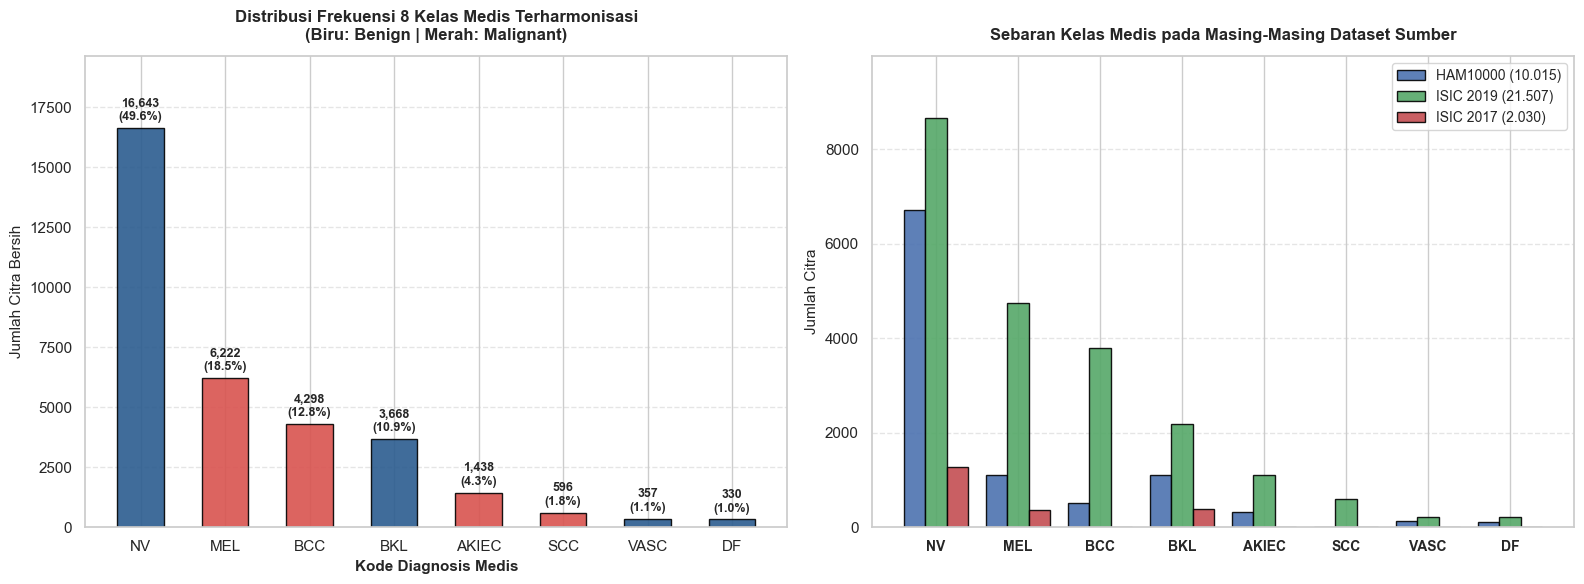

In [7]:
# =========================================================================
# 3.6 VISUALISASI GRAFIK BATANG PENYATUAN KELAS LINTAS DATASET
# =========================================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Total Distribusi 8 Kelas Medis Terharmonisasi (Tanpa UNK)
ax_a = axes1[0]
valid_classes = [c for c in ORDERED_CLASSES if c != 'UNK']
cls_counts_valid = [int((df_clean['unified_class'] == c).sum()) for c in valid_classes]
bar_colors = ['#2b5c8f' if UNIFIED_TARGET[c].startswith('Benign') else '#d9534f' for c in valid_classes]

bars = ax_a.bar(valid_classes, cls_counts_valid, color=bar_colors, edgecolor='black', alpha=0.9, width=0.55)
ax_a.set_title("Distribusi Frekuensi 8 Kelas Medis Terharmonisasi\n(Biru: Benign | Merah: Malignant)", fontsize=12, fontweight='bold', pad=12)
ax_a.set_ylabel("Jumlah Citra Bersih", fontsize=11)
ax_a.set_xlabel("Kode Diagnosis Medis", fontsize=11, fontweight='bold')
ax_a.set_ylim(0, max(cls_counts_valid) * 1.18)
ax_a.grid(axis='y', linestyle='--', alpha=0.5)

for b in bars:
    h = b.get_height()
    pct = h / sum(cls_counts_valid) * 100
    ax_a.text(b.get_x() + b.get_width()/2.0, h + 200, f"{int(h):,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot B: Breakdown Per Dataset Sumber (Grouped Bar Chart)
ax_b = axes1[1]
x_pos = np.arange(len(valid_classes))
width_b = 0.26

ham_vals = [int(((df_clean['dataset_family'] == 'HAM10000') & (df_clean['unified_class'] == c)).sum()) for c in valid_classes]
isic19_vals = [int(((df_clean['dataset_family'] == 'ISIC 2019') & (df_clean['unified_class'] == c)).sum()) for c in valid_classes]
isic17_vals = [int(((df_clean['dataset_family'] == 'ISIC 2017') & (df_clean['unified_class'] == c)).sum()) for c in valid_classes]

r1 = ax_b.bar(x_pos - width_b, ham_vals, width=width_b, label='HAM10000 (10.015)', color='#4c72b0', edgecolor='black', alpha=0.9)
r2 = ax_b.bar(x_pos, isic19_vals, width=width_b, label='ISIC 2019 (21.507)', color='#55a868', edgecolor='black', alpha=0.9)
r3 = ax_b.bar(x_pos + width_b, isic17_vals, width=width_b, label='ISIC 2017 (2.030)', color='#c44e52', edgecolor='black', alpha=0.9)

ax_b.set_xticks(x_pos)
ax_b.set_xticklabels(valid_classes, fontsize=10, fontweight='bold')
ax_b.set_ylabel("Jumlah Citra", fontsize=11)
ax_b.set_title("Sebaran Kelas Medis pada Masing-Masing Dataset Sumber", fontsize=12, fontweight='bold', pad=12)
ax_b.legend(fontsize=10)
ax_b.set_ylim(0, max(max(ham_vals), max(isic19_vals)) * 1.15)
ax_b.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Langkah 8: Rujukan Paper Ilmiah Internasional (Biner & Multiclass)
Menentukan apakah suatu penyakit kulit tergolong **Jinak** atau **Ganas** memiliki dasar ilmiah yang selaras dengan skenario multiclass:
- **Koneksi dengan Rujukan Multiclass (Tschandl 2018 & Codella 2018):**
  - `NV` (Tahi lalat) & `BKL` (Keratosis jinak) = **Jinak (Benign / 0)**
  - `MEL` (Melanoma) = **Ganas (Malignant / 1)**
- **Rujukan Pendukung Tambahan Biner (Q1 Elsevier & MDPI):**
  1. **ISIC 2017:** Catarina Barata et al. (*Pattern Recognition, Elsevier 2020*)
  2. **HAM10000:** Ioannis Kousis et al. (*MDPI Electronics 2022*) & SkinNet-16 (*Frontiers 2022*)
  3. **ISIC 2019:** MorphoNet / Bradley Yao et al. (*MDPI Bioengineering 2026*)

In [8]:
# 1. Paper acuan utama: Dataset Primer (Multiclass) & Rujukan Biner
df_main_ref = pd.DataFrame([
    {
        'Dataset': 'ISIC 2017',
        'Paper Primer (Multiclass)': 'Codella et al. (IEEE ISBI 2018)',
        'Rujukan Pemetaan Biner': 'Catarina Barata et al. (Elsevier Q1 2020)',
        'Benign (0)': 'nevus (NV), seborrheic_keratosis (BKL)',
        'Malignant (1)': 'melanoma (MEL)'
    },
    {
        'Dataset': 'HAM10000',
        'Paper Primer (Multiclass)': 'Tschandl et al. (Nature Sci Data 2018)',
        'Rujukan Pemetaan Biner': 'Ioannis Kousis et al. (MDPI Electronics 2022)',
        'Benign (0)': 'nv, bkl, df, vasc',
        'Malignant (1)': 'mel, bcc, akiec'
    },
    {
        'Dataset': 'ISIC 2019',
        'Paper Primer (Multiclass)': 'Combalia et al. (arXiv / ISIC 2019)',
        'Rujukan Pemetaan Biner': 'MorphoNet / Yao et al. (MDPI 2026)',
        'Benign (0)': 'NV, BKL, DF, VASC',
        'Malignant (1)': 'MEL, BCC, AKIEC, SCC'
    }
])
display(df_main_ref)

# 2. Rekap literatur pendukung
df_lit = pd.DataFrame([
    {'Dataset': 'ISIC 2017', 'Paper': 'Barata et al. (2020)', 'Penerbit': 'Elsevier', 'Benign': 'nevus, seborrheic_keratosis', 'Malignant': 'melanoma'},
    {'Dataset': 'ISIC 2017', 'Paper': 'Jojoa Acosta et al. (2021)', 'Penerbit': 'Springer', 'Benign': 'Nevus, Seborrheic Keratosis', 'Malignant': 'Melanoma'},
    {'Dataset': 'HAM10000', 'Paper': 'Harangi et al. (2020)', 'Penerbit': 'Elsevier', 'Benign': 'bkl, df, nv', 'Malignant': 'mel, bcc, akiec, vasc*'},
    {'Dataset': 'HAM10000', 'Paper': 'Kousis et al. (2022)', 'Penerbit': 'MDPI', 'Benign': 'nv, bkl, vasc, df', 'Malignant': 'mel, bcc, akiec'},
    {'Dataset': 'HAM10000', 'Paper': 'SkinNet-16 / Ghosh (2022)', 'Penerbit': 'Frontiers', 'Benign': 'df, bkl, vasc, nv', 'Malignant': 'bcc, mel, akiec'},
    {'Dataset': 'HAM10000', 'Paper': 'Ameri (2020)', 'Penerbit': 'JBPE', 'Benign': 'df, nv, bkl', 'Malignant': 'mel, bcc, akiec (vasc exclude)'},
    {'Dataset': 'ISIC 2019', 'Paper': 'MorphoNet / Yao (2026)', 'Penerbit': 'MDPI', 'Benign': 'NV, BKL, DF, VASC', 'Malignant': 'MEL, BCC, AKIEC, SCC'},
    {'Dataset': 'ISIC 2019', 'Paper': 'Venugopal et al. (2023)', 'Penerbit': 'Elsevier', 'Benign': 'NV, BKL, AK*, UNK', 'Malignant': 'MEL, BCC, SCC'}
])
display(df_lit)

# 3. Hasil voting & justifikasi medis
df_voting = pd.DataFrame([
    {'Kelas': 'NV (Nevus)', 'Suara Benign': '8 (100%)', 'Suara Malignant': '0 (0%)', 'Target': 'Benign (0)', 'Catatan Medis': 'Tahi lalat biasa (non-kanker)'},
    {'Kelas': 'BKL (Keratosis)', 'Suara Benign': '8 (100%)', 'Suara Malignant': '0 (0%)', 'Target': 'Benign (0)', 'Catatan Medis': 'Keratosis seboroik jinak'},
    {'Kelas': 'DF', 'Suara Benign': '5 (100%)', 'Suara Malignant': '0 (0%)', 'Target': 'Benign (0)', 'Catatan Medis': 'Dermatofibroma jinak'},
    {'Kelas': 'VASC', 'Suara Benign': '4 (80%)', 'Suara Malignant': '1 (20%)', 'Target': 'Benign (0)', 'Catatan Medis': 'Lesi vaskular jinak (cherry angioma/hemangioma)'},
    {'Kelas': 'MEL (Melanoma)', 'Suara Benign': '0 (0%)', 'Suara Malignant': '8 (100%)', 'Target': 'Malignant (1)', 'Catatan Medis': 'Kanker melanoma ganas'},
    {'Kelas': 'BCC', 'Suara Benign': '0 (0%)', 'Suara Malignant': '6 (100%)', 'Target': 'Malignant (1)', 'Catatan Medis': 'Karsinoma sel basal ganas'},
    {'Kelas': 'SCC', 'Suara Benign': '0 (0%)', 'Suara Malignant': '2 (100%)', 'Target': 'Malignant (1)', 'Catatan Medis': 'Karsinoma sel skuamosa ganas'},
    {'Kelas': 'AKIEC / AK', 'Suara Benign': '1 (17%)', 'Suara Malignant': '5 (83%)', 'Target': 'Malignant (1)', 'Catatan Medis': 'Lesi pra-kanker (Bowen disease / karsinoma in situ)'}
])
display(df_voting)

,Dataset,Paper Primer (Multiclass),Rujukan Pemetaan Biner,Benign (0),Malignant (1)
0,ISIC 2017,Codella et al. (IEEE ISBI 2018),Catarina Barata et al. (Elsevier Q1 2020),"nevus (NV), seborrheic_keratosis (BKL)",melanoma (MEL)
1,HAM10000,Tschandl et al. (Nature Sci Data 2018),Ioannis Kousis et al. (MDPI Electronics 2022),"nv, bkl, df, vasc","mel, bcc, akiec"
2,ISIC 2019,Combalia et al. (arXiv / ISIC 2019),MorphoNet / Yao et al. (MDPI 2026),"NV, BKL, DF, VASC","MEL, BCC, AKIEC, SCC"


,Dataset,Paper,Penerbit,Benign,Malignant
0,ISIC 2017,Barata et al. (2020),Elsevier,"nevus, seborrheic_keratosis",melanoma
1,ISIC 2017,Jojoa Acosta et al. (2021),Springer,"Nevus, Seborrheic Keratosis",Melanoma
2,HAM10000,Harangi et al. (2020),Elsevier,"bkl, df, nv","mel, bcc, akiec, vasc*"
3,HAM10000,Kousis et al. (2022),MDPI,"nv, bkl, vasc, df","mel, bcc, akiec"
4,HAM10000,SkinNet-16 / Ghosh (2022),Frontiers,"df, bkl, vasc, nv","bcc, mel, akiec"
5,HAM10000,Ameri (2020),JBPE,"df, nv, bkl","mel, bcc, akiec (vasc exclude)"
6,ISIC 2019,MorphoNet / Yao (2026),MDPI,"NV, BKL, DF, VASC","MEL, BCC, AKIEC, SCC"
7,ISIC 2019,Venugopal et al. (2023),Elsevier,"NV, BKL, AK*, UNK","MEL, BCC, SCC"


,Kelas,Suara Benign,Suara Malignant,Target,Catatan Medis
0,NV (Nevus),8 (100%),0 (0%),Benign (0),Tahi lalat biasa (non-kanker)
1,BKL (Keratosis),8 (100%),0 (0%),Benign (0),Keratosis seboroik jinak
2,DF,5 (100%),0 (0%),Benign (0),Dermatofibroma jinak
3,VASC,4 (80%),1 (20%),Benign (0),Lesi vaskular jinak (cherry angioma/hemangioma)
4,MEL (Melanoma),0 (0%),8 (100%),Malignant (1),Kanker melanoma ganas
5,BCC,0 (0%),6 (100%),Malignant (1),Karsinoma sel basal ganas
6,SCC,0 (0%),2 (100%),Malignant (1),Karsinoma sel skuamosa ganas
7,AKIEC / AK,1 (17%),5 (83%),Malignant (1),Lesi pra-kanker (Bowen disease / karsinoma in ...


## Langkah 9: Aturan Pengelompokan Biner (Jinak vs Ganas)
Berdasarkan rujukan jurnal medis di atas, kita kelompokkan 8 penyakit menjadi:
- **Jinak / Benign (0):** `NV` (Tahi lalat), `BKL` (Keratosis jinak), `DF` (Dermatofibroma), `VASC` (Lesi vaskular).
- **Ganas / Malignant (1):** `MEL` (Melanoma), `BCC` (Karsinoma sel basal), `AKIEC` (Karsinoma sel skuamosa in-situ), `SCC` (Karsinoma sel skuamosa).
- **Dibuang:** `UNK` (Foto tanpa diagnosis klinis pasti, dibuang agar tidak merusak pembelajaran AI).

In [9]:
# Kamus aturan biner
BINARY_RULES = {
    'NV': 0, 'BKL': 0, 'DF': 0, 'VASC': 0,
    'MEL': 1, 'BCC': 1, 'AKIEC': 1, 'SCC': 1
}

BINARY_NAMES = {0: 'Benign', 1: 'Malignant'}

for k, v in BINARY_RULES.items():
    print(f"{k:<10} -> {BINARY_NAMES[v]} ({v})")


NV         -> Benign (0)
BKL        -> Benign (0)
DF         -> Benign (0)
VASC       -> Benign (0)
MEL        -> Malignant (1)
BCC        -> Malignant (1)
AKIEC      -> Malignant (1)
SCC        -> Malignant (1)


## Langkah 10: Terapkan Pengelompokan & Buang Data 'UNK'
Sekarang kita terapkan aturan di atas ke seluruh data kita.
- Sebanyak 2.047 sampel `UNK` kita hapus.
- **Hasil Akhir:** Tersisa **33.552 data valid**, dengan rincian:
  - **Jinak / Benign (0):** 20.998 foto (62.6%)
  - **Ganas / Malignant (1):** 12.554 foto (37.4%)

In [10]:
# Terapkan mapping biner pada kelas terharmonisasi
df_binary = df_clean.copy()
df_binary['target_binary'] = df_binary['unified_class'].map(BINARY_RULES)
df_binary['binary_class'] = df_binary['target_binary'].map(BINARY_NAMES)

# Drop data UNK (out of distribution)
n_unk = df_binary['target_binary'].isna().sum()
if n_unk > 0:
    print(f"Data 'UNK' di-drop : {n_unk:,} sampel")
    df_binary = df_binary.dropna(subset=['target_binary']).copy()

df_binary['target_binary'] = df_binary['target_binary'].astype(int)

print(f"Total data valid   : {len(df_binary):,}")
print(f"- Benign (0)       : {(df_binary['target_binary'] == 0).sum():,} ({(df_binary['target_binary'] == 0).sum()/len(df_binary)*100:.1f}%)")
print(f"- Malignant (1)    : {(df_binary['target_binary'] == 1).sum():,} ({(df_binary['target_binary'] == 1).sum()/len(df_binary)*100:.1f}%)")
print(f"- Missing target   : {df_binary['target_binary'].isna().sum()}")

display(df_binary[['image_id', 'source', 'original_label', 'unified_class', 'binary_class', 'target_binary']].head(10))


Data 'UNK' di-drop : 2,047 sampel
Total data valid   : 33,552
- Benign (0)       : 20,998 (62.6%)
- Malignant (1)    : 12,554 (37.4%)
- Missing target   : 0


,image_id,source,original_label,unified_class,binary_class,target_binary
10015,ISIC_0000000,isic_2019_train,NV,NV,Benign,0
10016,ISIC_0000001,isic_2019_train,NV,NV,Benign,0
10017,ISIC_0000002,isic_2019_train,MEL,MEL,Malignant,1
10018,ISIC_0000003,isic_2019_train,NV,NV,Benign,0
10019,ISIC_0000004,isic_2019_train,MEL,MEL,Malignant,1
10020,ISIC_0000006,isic_2019_train,NV,NV,Benign,0
10021,ISIC_0000007,isic_2019_train,NV,NV,Benign,0
10022,ISIC_0000008,isic_2019_train,NV,NV,Benign,0
10023,ISIC_0000009,isic_2019_train,NV,NV,Benign,0
10024,ISIC_0000010,isic_2019_train,NV,NV,Benign,0


## Langkah 11: Rekapitulasi Data & Grafik Perbandingan Akhir
Tabel di bawah merangkum jumlah sampel Benign dan Malignant untuk setiap partisi dataset sumber (Training, Validation, dan Test).

In [11]:
# Rekapitulasi per sumber dataset dan keluarga dataset
sources_eval = ['ham10000', 'isic_2019_train', 'isic_2019_test', 'isic_2017_train', 'isic_2017_val', 'isic_2017_test']
rekap_rows = []

for src in sources_eval:
    sub = df_binary[df_binary['source'] == src]
    if len(sub) == 0:
        continue
    n_b = int((sub['target_binary'] == 0).sum())
    n_m = int((sub['target_binary'] == 1).sum())
    total = len(sub)
    rekap_rows.append({
        'Source Dataset': src,
        'Total': f"{total:,}",
        'Benign (0)': f"{n_b:,} ({n_b/total*100:.1f}%)",
        'Malignant (1)': f"{n_m:,} ({n_m/total*100:.1f}%)",
        'Rasio B:M': f"{n_b/n_m:.2f} : 1" if n_m > 0 else "-"
    })

# Subtotal per keluarga dataset
for fam in ['HAM10000', 'ISIC 2019', 'ISIC 2017']:
    sub = df_binary[df_binary['dataset_family'] == fam]
    n_b = int((sub['target_binary'] == 0).sum())
    n_m = int((sub['target_binary'] == 1).sum())
    total = len(sub)
    rekap_rows.append({
        'Source Dataset': f"SUBTOTAL {fam}",
        'Total': f"{total:,}",
        'Benign (0)': f"{n_b:,} ({n_b/total*100:.1f}%)",
        'Malignant (1)': f"{n_m:,} ({n_m/total*100:.1f}%)",
        'Rasio B:M': f"{n_b/n_m:.2f} : 1" if n_m > 0 else "-"
    })

tot_b = int((df_binary['target_binary'] == 0).sum())
tot_m = int((df_binary['target_binary'] == 1).sum())
tot_all = len(df_binary)

rekap_rows.append({
    'Source Dataset': 'TOTAL GABUNGAN',
    'Total': f"{tot_all:,}",
    'Benign (0)': f"{tot_b:,} ({tot_b/tot_all*100:.1f}%)",
    'Malignant (1)': f"{tot_m:,} ({tot_m/tot_all*100:.1f}%)",
    'Rasio B:M': f"{tot_b/tot_m:.2f} : 1"
})

df_summary = pd.DataFrame(rekap_rows)
display(df_summary)


,Source Dataset,Total,Benign (0),Malignant (1),Rasio B:M
0,ham10000,"10,015","8,061 (80.5%)","1,954 (19.5%)",4.13 : 1
1,isic_2019_train,"15,316","7,930 (51.8%)","7,386 (48.2%)",1.07 : 1
2,isic_2019_test,"6,191","3,350 (54.1%)","2,841 (45.9%)",1.18 : 1
3,isic_2017_train,"1,283","1,056 (82.3%)",227 (17.7%),4.65 : 1
4,isic_2017_val,148,118 (79.7%),30 (20.3%),3.93 : 1
5,isic_2017_test,599,483 (80.6%),116 (19.4%),4.16 : 1
6,SUBTOTAL HAM10000,"10,015","8,061 (80.5%)","1,954 (19.5%)",4.13 : 1
7,SUBTOTAL ISIC 2019,"21,507","11,280 (52.4%)","10,227 (47.6%)",1.10 : 1
8,SUBTOTAL ISIC 2017,"2,030","1,657 (81.6%)",373 (18.4%),4.44 : 1
9,TOTAL GABUNGAN,"33,552","20,998 (62.6%)","12,554 (37.4%)",1.67 : 1


### Visualisasi Distribusi Jinak (Benign) vs Ganas (Malignant)
Grafik di bawah memperlihatkan perbandingan total kelas biner dan rincian proporsinya di tiap dataset sumber.

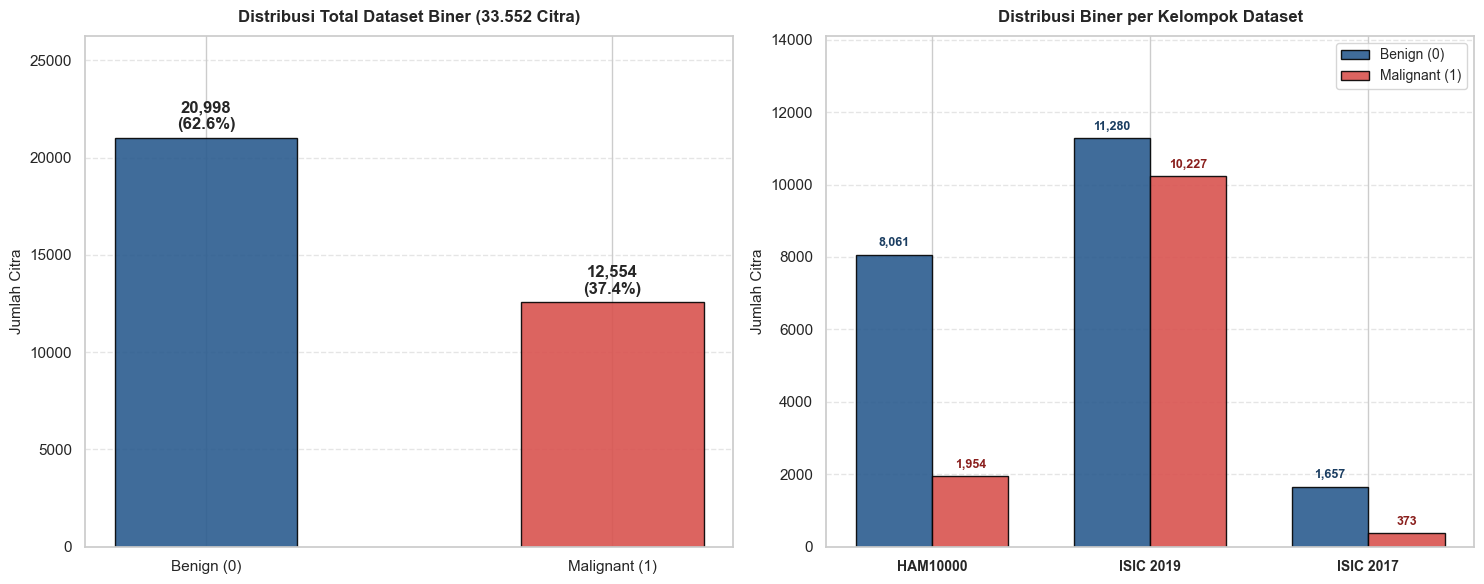

In [12]:
# Visualisasi grafik batang distribusi biner
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))

# 1. Total distribusi biner
ax2_1 = axes2[0]
counts_total = [tot_b, tot_m]
labels_total = ['Benign (0)', 'Malignant (1)']
colors_bin = ['#2b5c8f', '#d9534f']

bars_bin = ax2_1.bar(labels_total, counts_total, color=colors_bin, width=0.45, edgecolor='black', alpha=0.9)
ax2_1.set_title("Distribusi Total Dataset Biner (33.552 Citra)", fontsize=12, fontweight='bold', pad=10)
ax2_1.set_ylabel("Jumlah Citra", fontsize=11)
ax2_1.set_ylim(0, max(counts_total) * 1.25)
ax2_1.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars_bin:
    h = bar.get_height()
    pct = h / tot_all * 100
    ax2_1.text(bar.get_x() + bar.get_width()/2.0, h + 300, f"{int(h):,}\n({pct:.1f}%)", ha='center', va='bottom', fontweight='bold')

# 2. Perbandingan per kelompok dataset
ax2_2 = axes2[1]
fam_ordered = ['HAM10000', 'ISIC 2019', 'ISIC 2017']
x_fam = np.arange(len(fam_ordered))
width_fam = 0.35

b_fams = [(df_binary[(df_binary['dataset_family'] == s) & (df_binary['target_binary'] == 0)]).shape[0] for s in fam_ordered]
m_fams = [(df_binary[(df_binary['dataset_family'] == s) & (df_binary['target_binary'] == 1)]).shape[0] for s in fam_ordered]

rects_b = ax2_2.bar(x_fam - width_fam/2, b_fams, width=width_fam, label='Benign (0)', color='#2b5c8f', edgecolor='black', alpha=0.9)
rects_m = ax2_2.bar(x_fam + width_fam/2, m_fams, width=width_fam, label='Malignant (1)', color='#d9534f', edgecolor='black', alpha=0.9)

max_fam = max(max(b_fams), max(m_fams))
ax2_2.set_ylim(0, max_fam * 1.25)
ax2_2.set_xticks(x_fam)
ax2_2.set_xticklabels(fam_ordered, fontsize=10, fontweight='bold')
ax2_2.set_ylabel("Jumlah Citra", fontsize=11)
ax2_2.set_title("Distribusi Biner per Kelompok Dataset", fontsize=12, fontweight='bold', pad=10)
ax2_2.legend(fontsize=10)
ax2_2.grid(axis='y', linestyle='--', alpha=0.5)

for rect in rects_b:
    h = rect.get_height()
    if h > 0:
        ax2_2.text(rect.get_x() + rect.get_width()/2.0, h + 150, f"{int(h):,}", ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1a3d61')

for rect in rects_m:
    h = rect.get_height()
    if h > 0:
        ax2_2.text(rect.get_x() + rect.get_width()/2.0, h + 150, f"{int(h):,}", ha='center', va='bottom', fontsize=9, fontweight='bold', color='#8a1f1d')

plt.tight_layout()
plt.show()


## Langkah 12: Simpan Dataset Bersih ke File CSV
Semua data yang sudah bersih dan terlabeli biner kita simpan ke file `dataset_binary_final.csv`. File ini yang siap digunakan untuk pelatihan model klasifikasi.

In [13]:
# Simpan ke CSV
output_csv = os.path.join(ROOT, 'dataset_binary_final.csv')
cols_export = ['image_id', 'source', 'original_label', 'unified_class', 'binary_class', 'target_binary', 'filepath']

df_binary[cols_export].to_csv(output_csv, index=False)

print(f"File tersimpan : {output_csv}")
print(f"Total data     : {len(df_binary):,} baris")
print(f"Kolom          : {', '.join(cols_export)}")

display(df_binary[cols_export].head(10))


File tersimpan : C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_binary_final.csv
Total data     : 33,552 baris
Kolom          : image_id, source, original_label, unified_class, binary_class, target_binary, filepath


,image_id,source,original_label,unified_class,binary_class,target_binary,filepath
10015,ISIC_0000000,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
10016,ISIC_0000001,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
10017,ISIC_0000002,isic_2019_train,MEL,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...
10018,ISIC_0000003,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
10019,ISIC_0000004,isic_2019_train,MEL,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...
10020,ISIC_0000006,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
10021,ISIC_0000007,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
10022,ISIC_0000008,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
10023,ISIC_0000009,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
10024,ISIC_0000010,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...


## Langkah 13: Cek Contoh Foto Nyata per Kategori
Sebagai pengecekan visual terakhir, kita tampilkan contoh foto asli untuk masing-masing kelas:
- 5 sampel lesi **Jinak (Benign)**
- 5 sampel lesi **Ganas (Malignant)**

,image_id,source,original_label,unified_class,binary_class,target_binary,filepath
0,ISIC_0000000,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
1,ISIC_0000001,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
2,ISIC_0000003,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
3,ISIC_0000006,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
4,ISIC_0000007,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
5,ISIC_0000002,isic_2019_train,MEL,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...
6,ISIC_0000004,isic_2019_train,MEL,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...
7,ISIC_0000013,isic_2019_train,MEL,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...
8,ISIC_0000022,isic_2017_train,melanoma,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...
9,ISIC_0000022_downsampled,isic_2019_train,MEL,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...


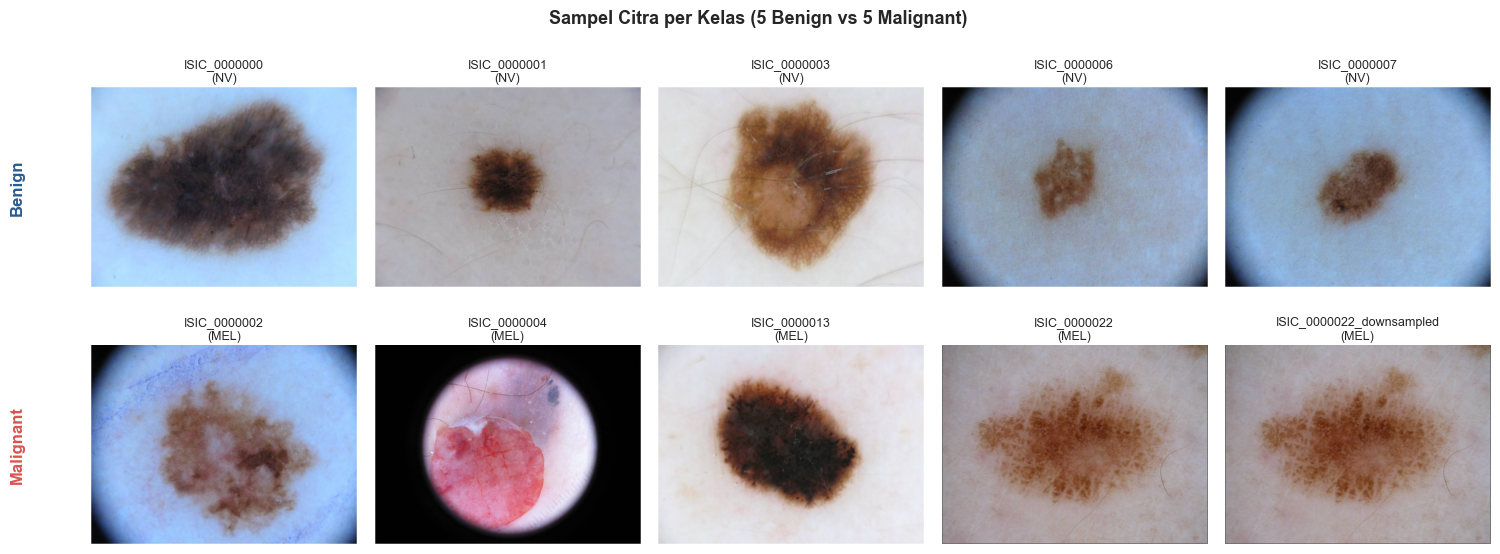

In [14]:
from PIL import Image

# 1. Tabel 5 sampel per kelas biner
sample_b = df_binary[df_binary['binary_class'] == 'Benign'].head(5)
sample_m = df_binary[df_binary['binary_class'] == 'Malignant'].head(5)
df_samples = pd.concat([sample_b, sample_m], ignore_index=True)

cols_show = ['image_id', 'source', 'original_label', 'unified_class', 'binary_class', 'target_binary', 'filepath']
display(df_samples[cols_show])

# 2. Visualisasi 5 gambar per kelas (Benign vs Malignant)
fig3, axes3 = plt.subplots(2, 5, figsize=(15, 6))

for row_idx, cls_name in enumerate(['Benign', 'Malignant']):
    subset = df_binary[df_binary['binary_class'] == cls_name].head(5)
    for col_idx, (_, r) in enumerate(subset.iterrows()):
        ax = axes3[row_idx, col_idx]
        if os.path.exists(r['filepath']):
            img = Image.open(r['filepath'])
            ax.imshow(img)
        iid = r['image_id']
        lbl = r['unified_class']
        ax.set_title(f"{iid}\n({lbl})", fontsize=9, pad=4)
        ax.axis('off')
        if col_idx == 0:
            ax.text(-0.25, 0.5, cls_name, transform=ax.transAxes,
                    fontsize=12, fontweight='bold', va='center', ha='right', rotation=90,
                    color='#2b5c8f' if cls_name == 'Benign' else '#d9534f')

plt.suptitle("Sampel Citra per Kelas (5 Benign vs 5 Malignant)", fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
